Code to create visualisations, and maybe the dispersion relation of the inertial waves seen in mainly the wide FOV results.

* filtered & reconstructed contours
* frequency vs dispersion relation

Boiler Plate Code here

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm
from scipy.ndimage import gaussian_filter
from scipy.signal import savgol_filter

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()

C:/Coding/Code
C:/Coding
Thesis plot settings applied


time shape
119
74
Filter Frequency = 0.3064Hz
Filter Frequency = 0.3064Hz
Filter Frequency = 0.3464Hz
Filter Frequency = 0.1035Hz


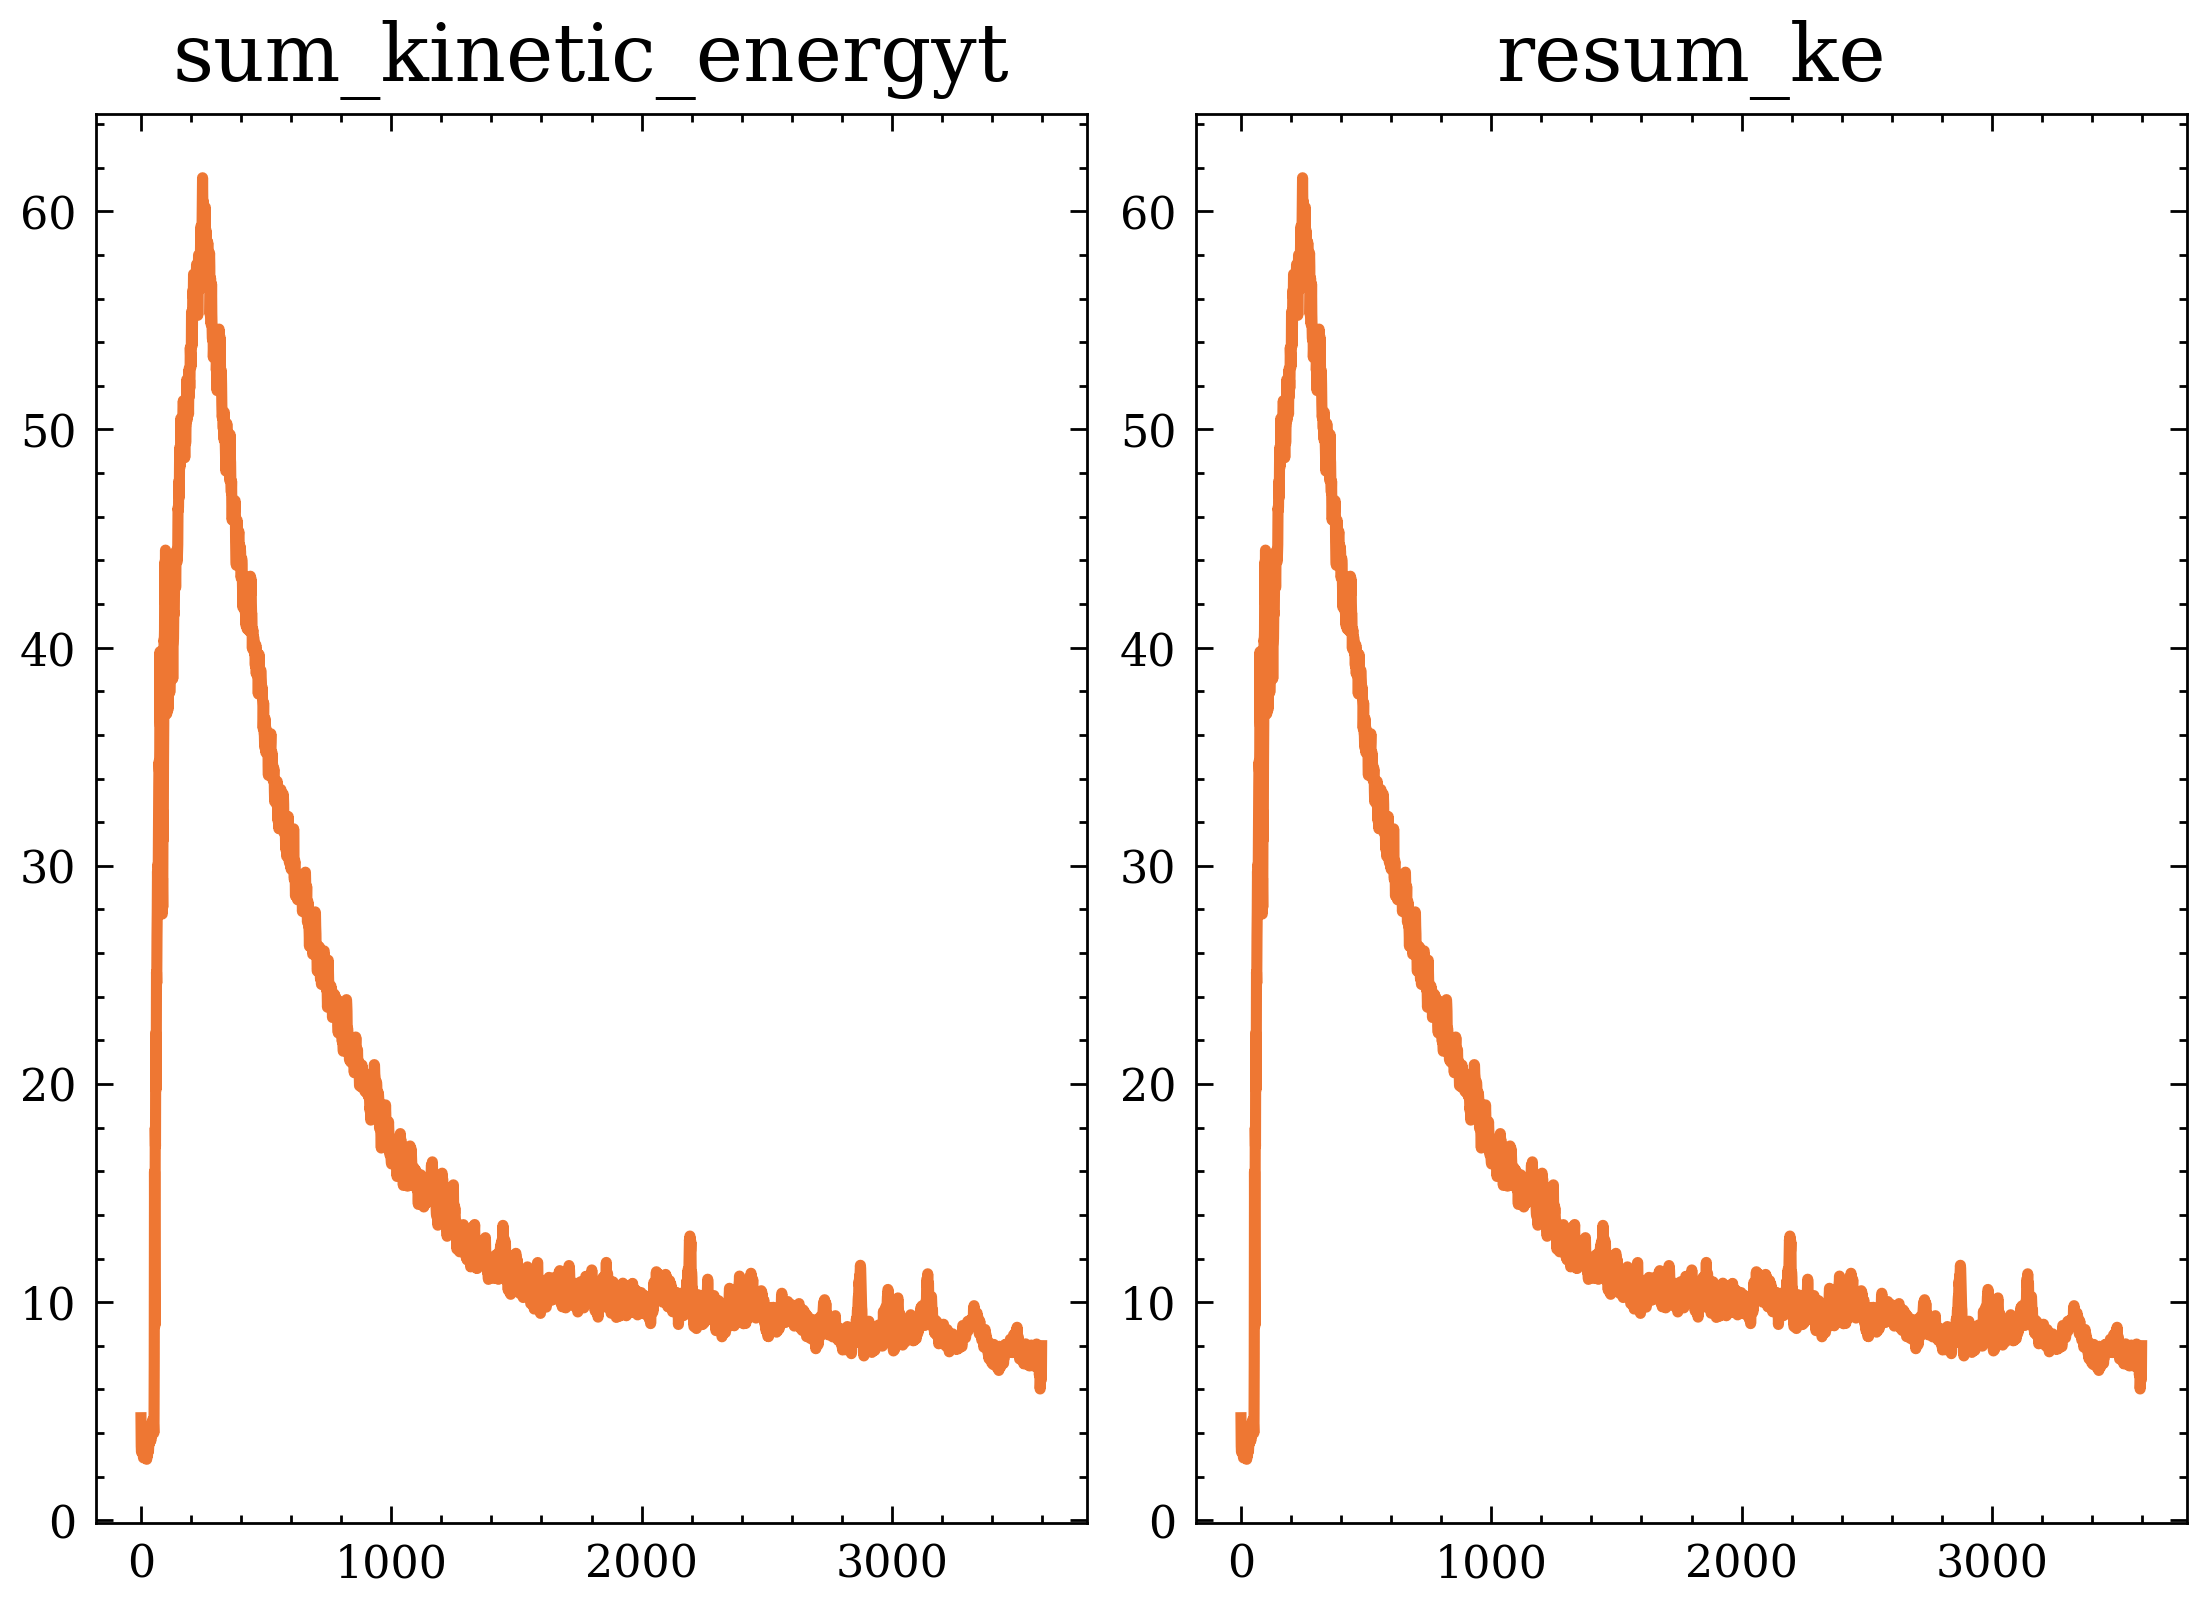

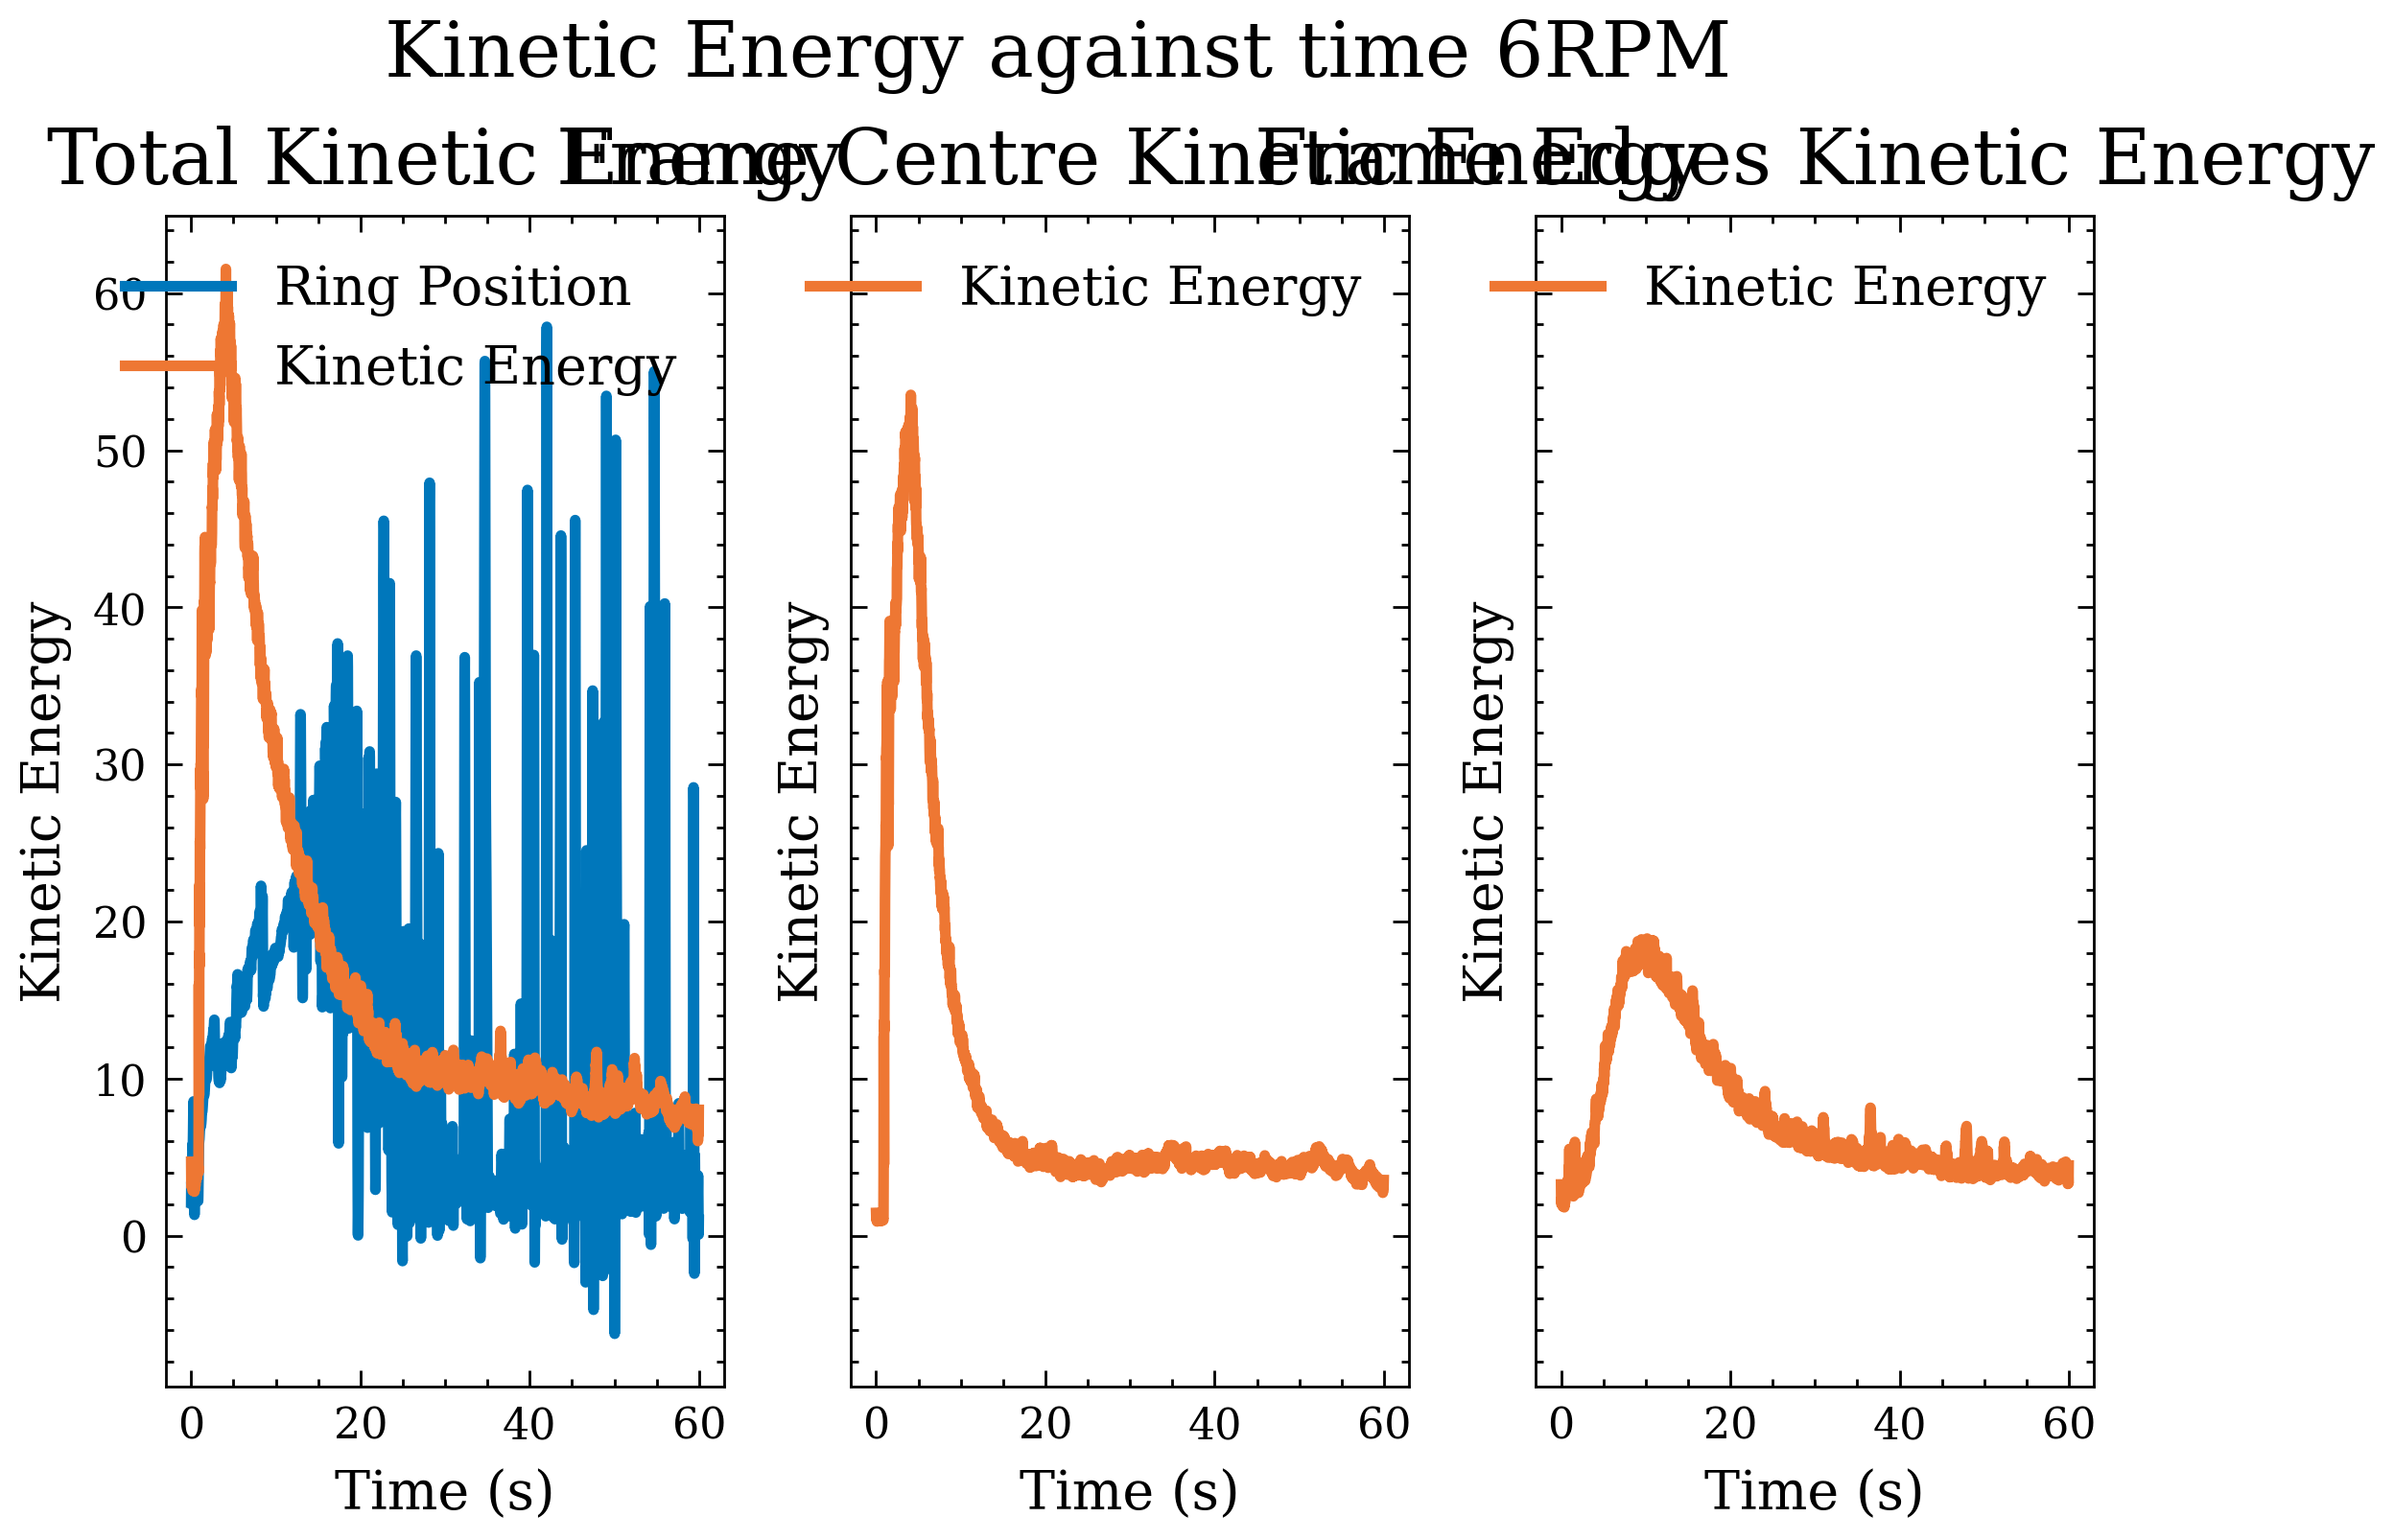

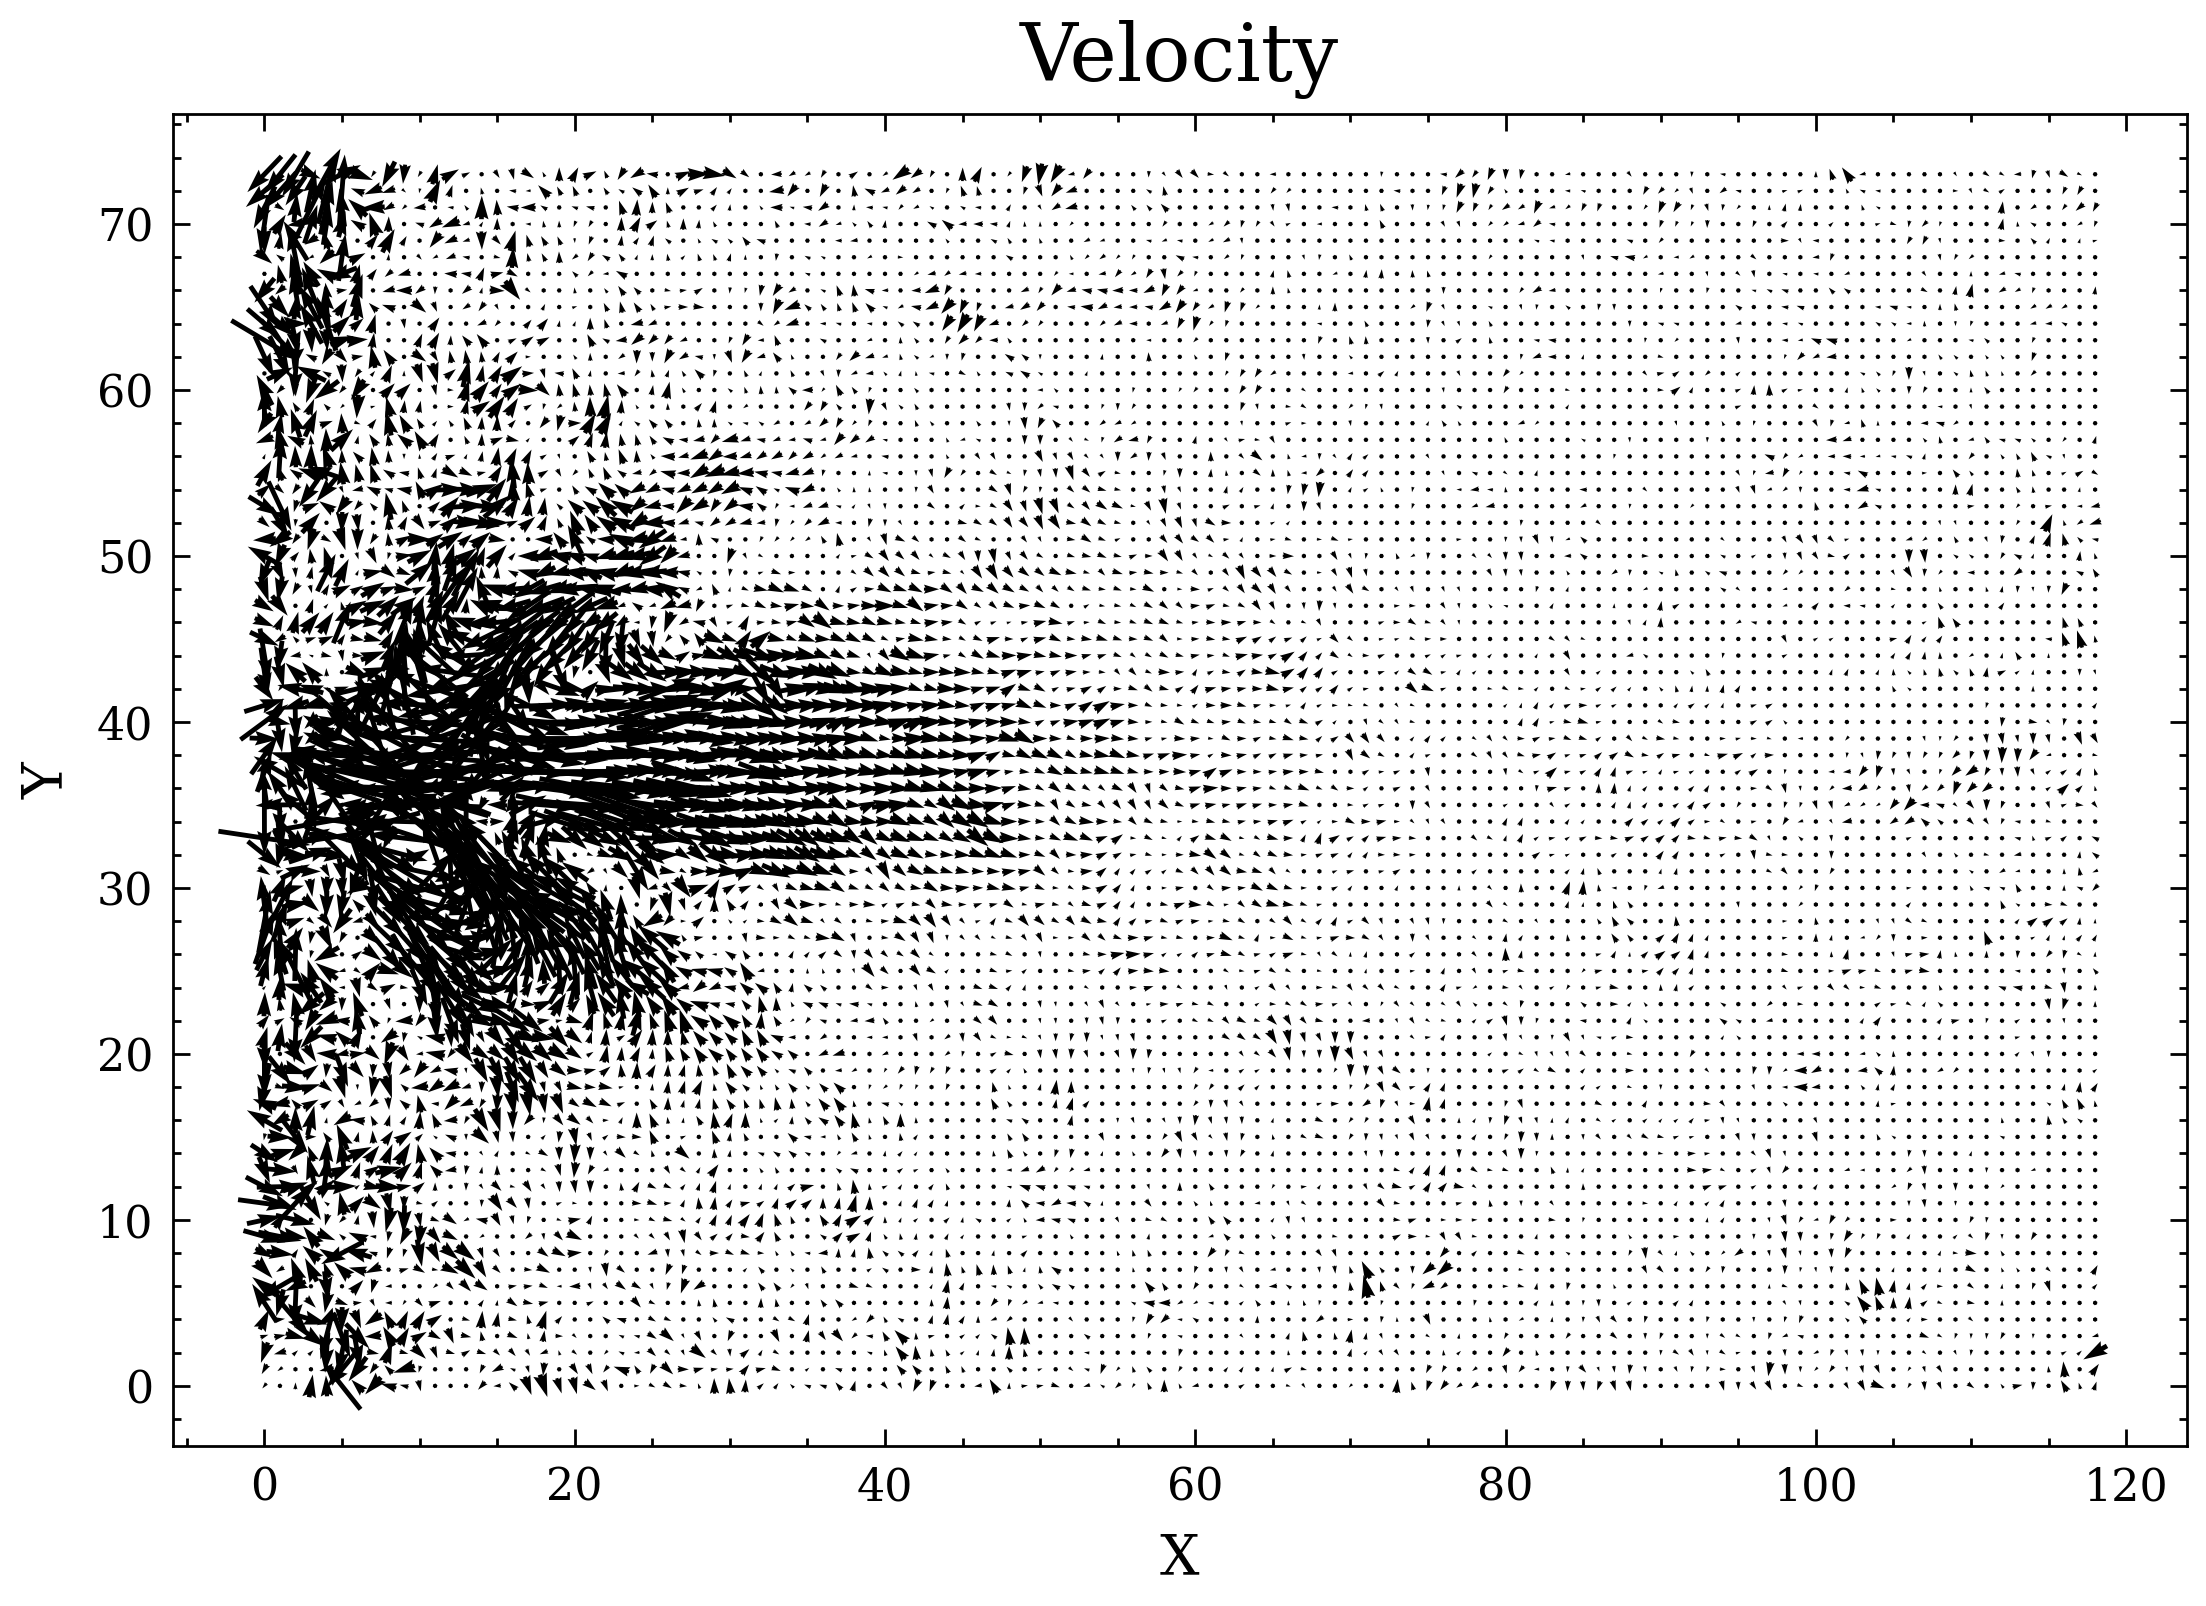

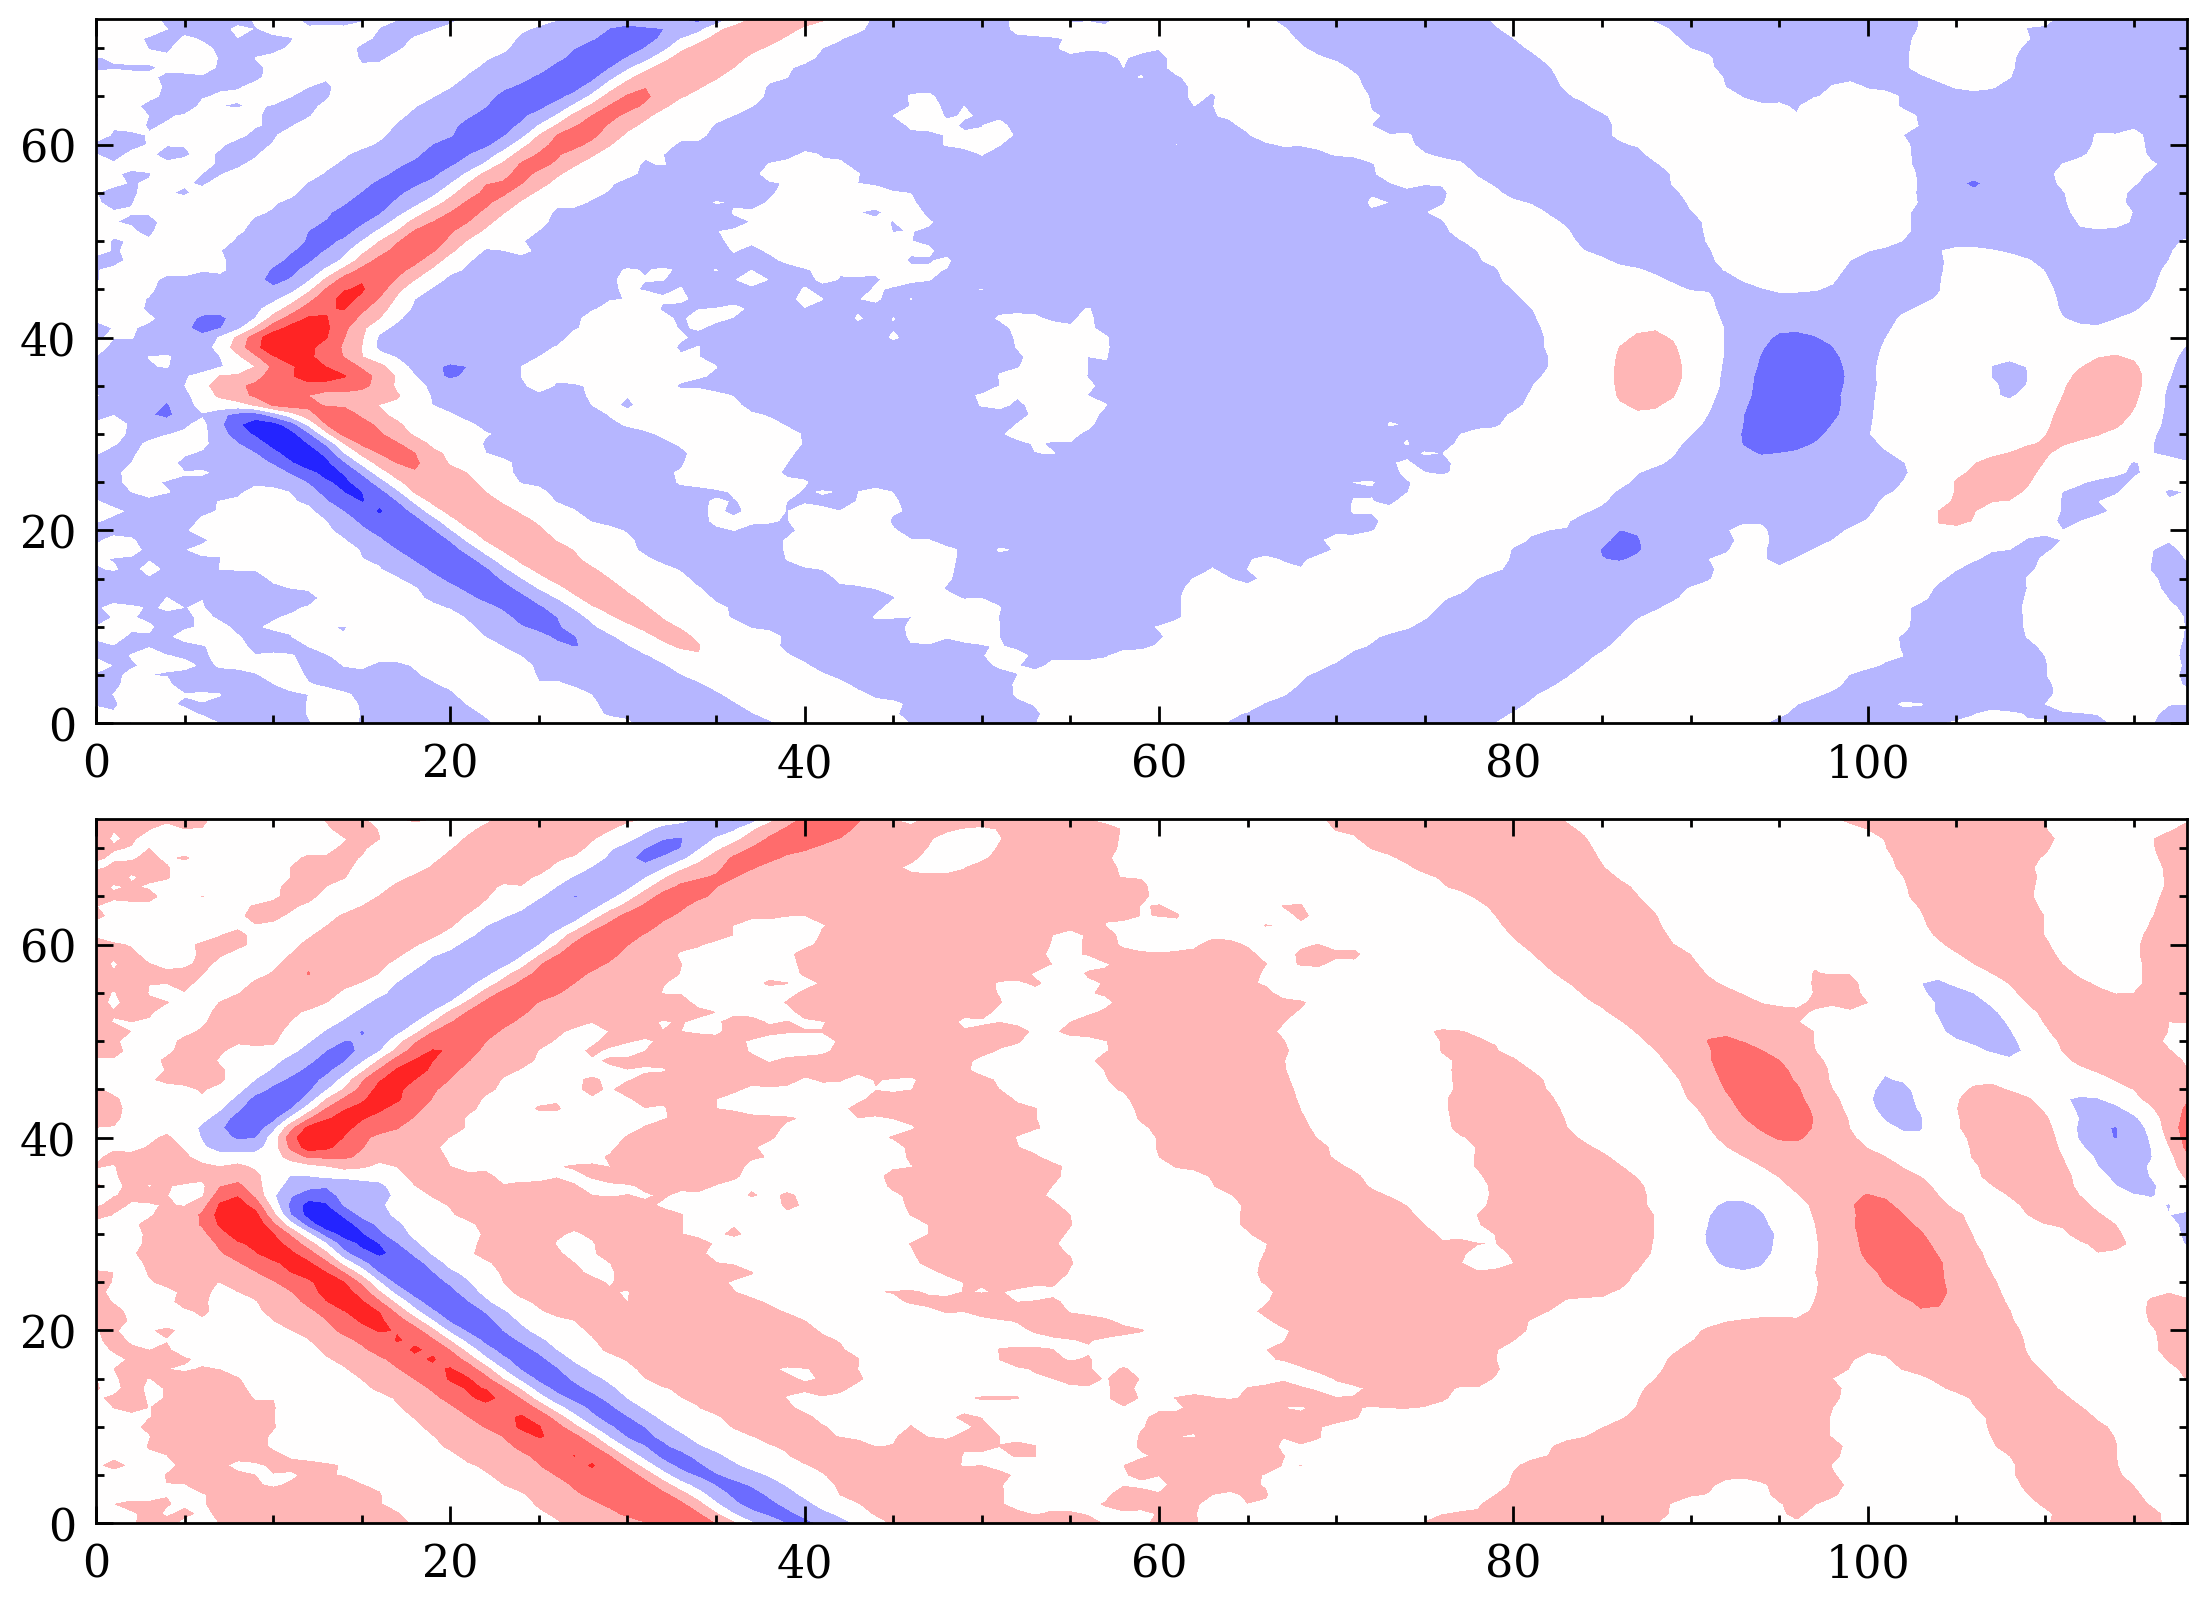

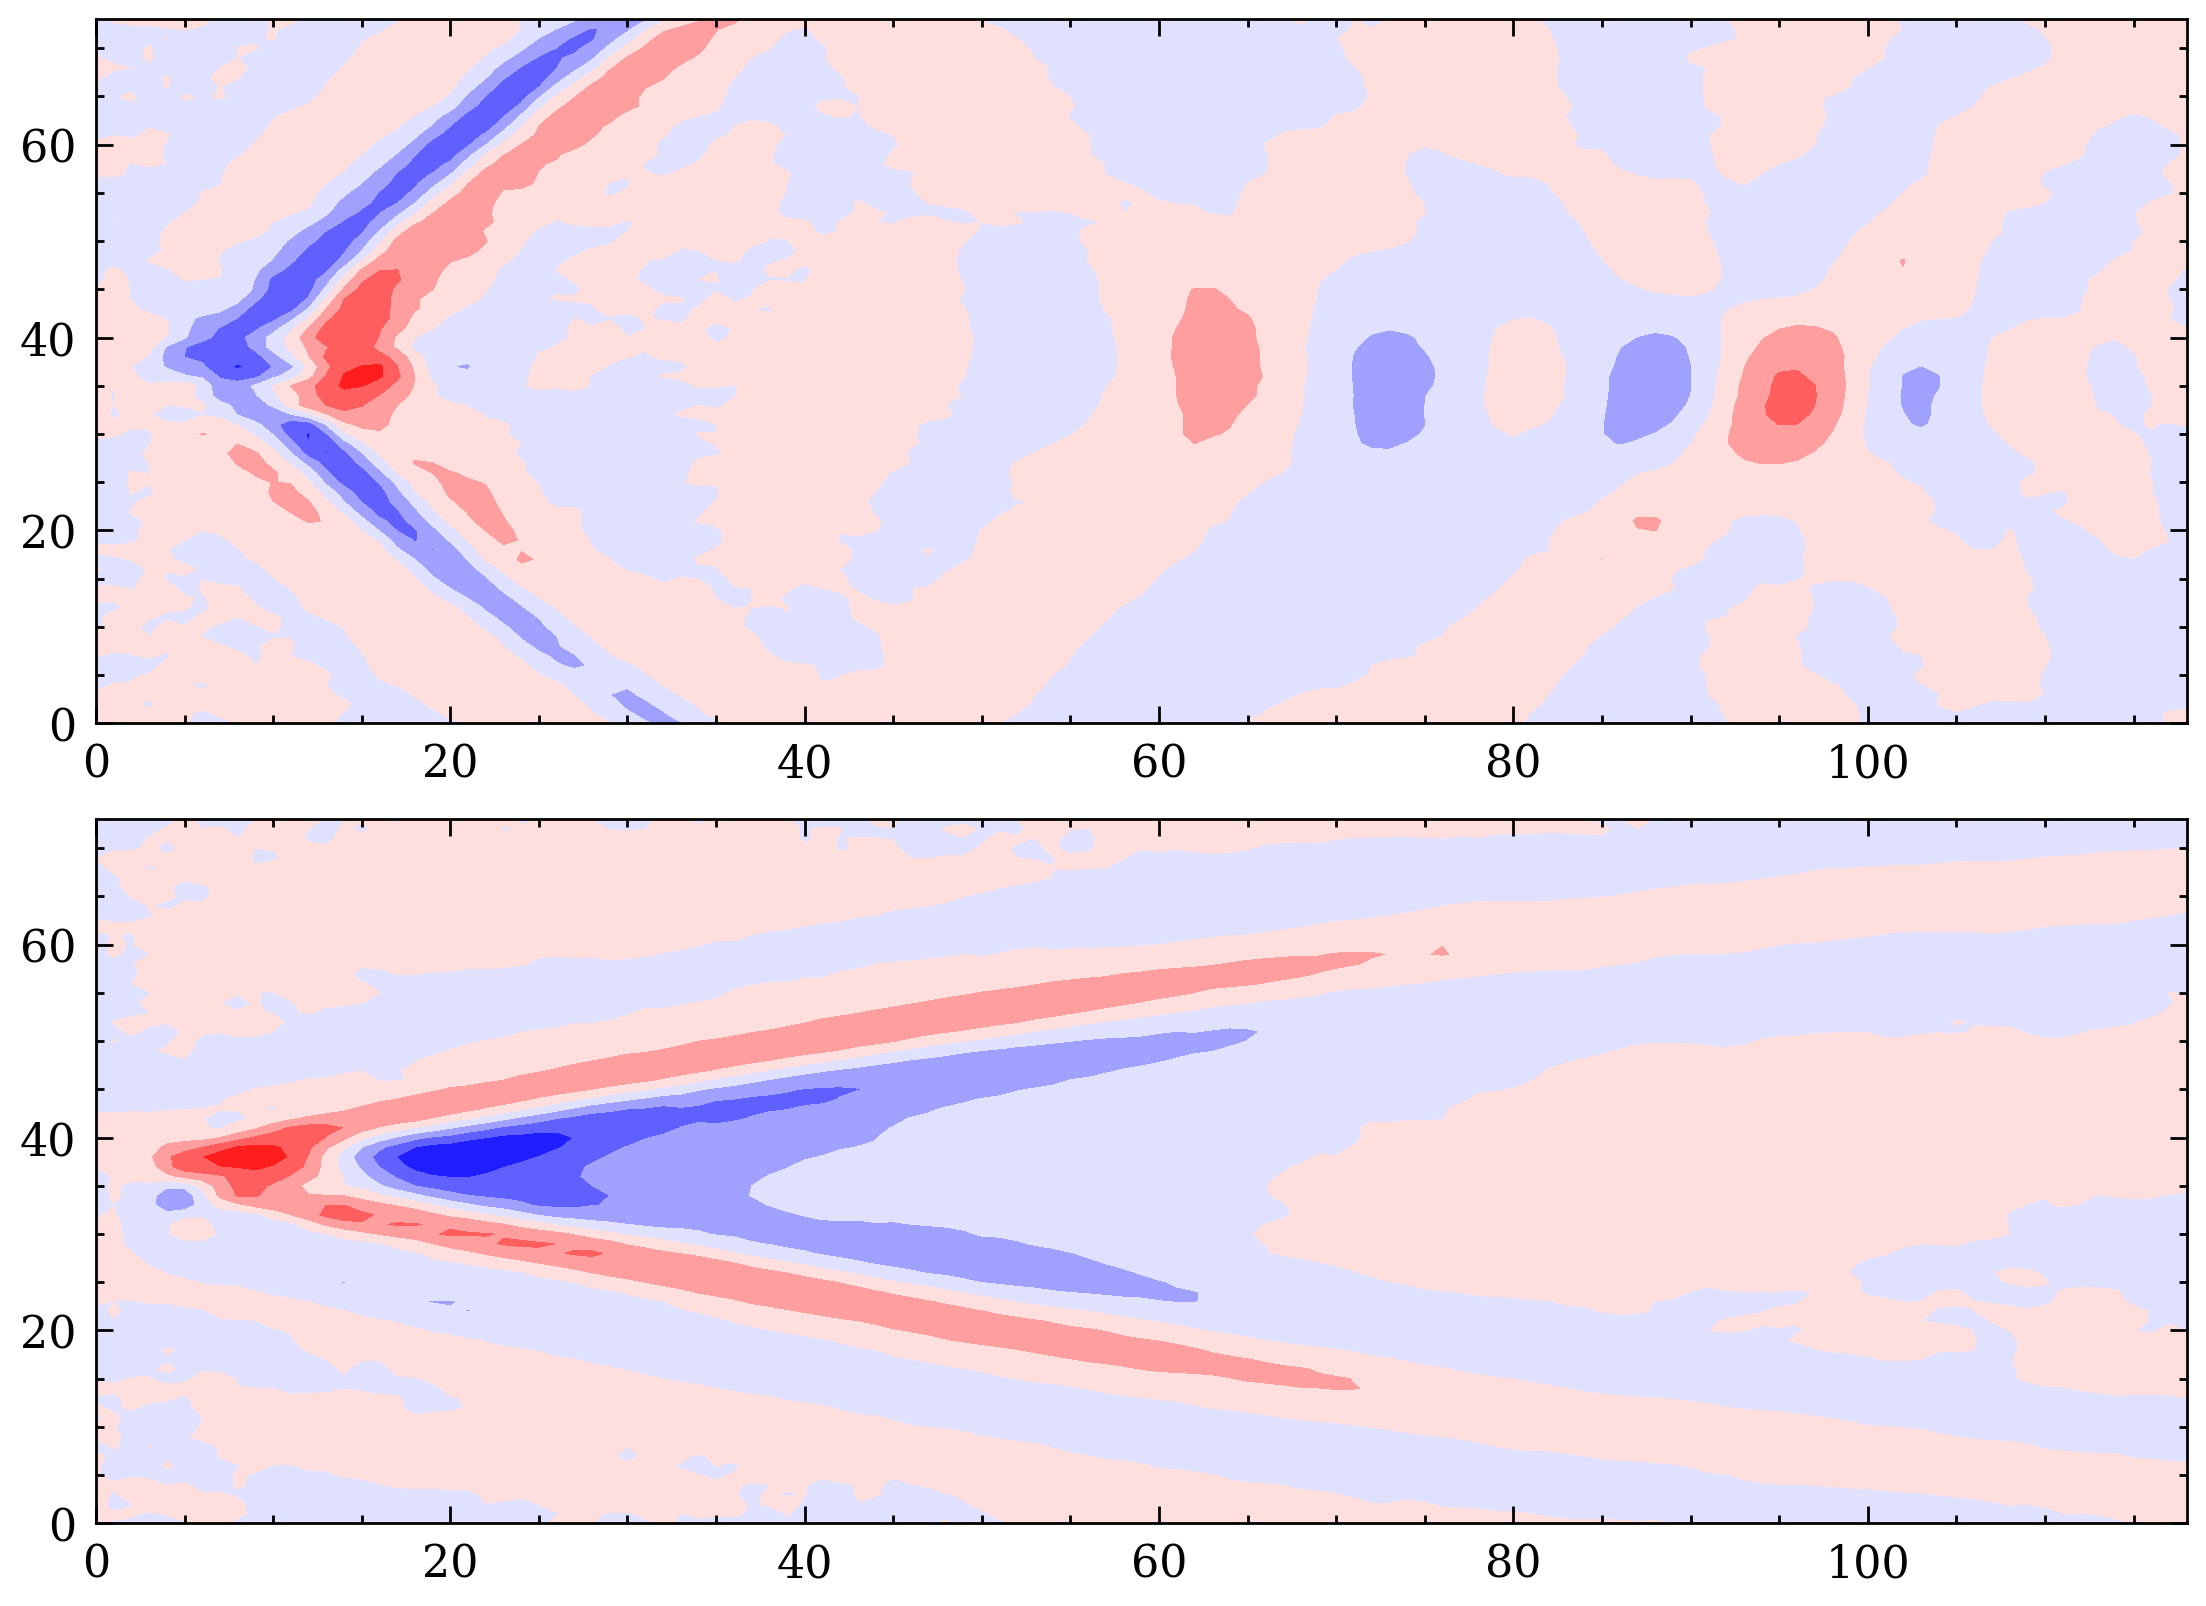

In [2]:
h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
vels = h5file['Wide']['U200']['L100']['RPM12']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
h5file.close()
u_gaussian, v_gaussian = gaussian_filter(u, sigma=0.7), gaussian_filter(v, sigma=0.7)

time = oj.frames_to_seconds(u, v, 60)
print("time shape")
# print(time.shape)

#### Calculating kinetic energy ####
kinetic_energyt, sum_kinetic_energyt = oj.sum_kinetic_energy(u_gaussian[:,:,:], v_gaussian[:,:,:])
sum_kinetic_energy_max = max(sum_kinetic_energyt)
sum_kinetic_energy_max_location = np.argmax(sum_kinetic_energyt)

#### Kinetic Energy centre and sides####
kinetic_energy_left, sum_kinetic_energy_left = oj.sum_kinetic_energy(u_gaussian[:, :25,:], v_gaussian[:, :25,:])
kinetic_energy_mid, sum_kinetic_energy_mid = oj.sum_kinetic_energy(u_gaussian[:,25:50,:], v_gaussian[:,25:50,:])
kinetic_energy_right, sum_kinetic_energy_right = oj.sum_kinetic_energy(u_gaussian[:, 50: ,:], v_gaussian[:, 50: ,:])

sum_kinetic_energy_sides = sum_kinetic_energy_left + sum_kinetic_energy_right

resum_ke = sum_kinetic_energy_sides + sum_kinetic_energy_mid

f1, (ax1, ax2) = plt.subplots(nrows=1,ncols=2)
ax1.plot(sum_kinetic_energyt)
ax1.set_title("sum_kinetic_energyt")
ax2.plot(resum_ke)
ax2.set_title("resum_ke")
# plt.show()

#### calculate vorticity and track ####

VortLocMax, VortLocMin = oj.vorticityPeakTracking(u_gaussian, v_gaussian, u.shape[0])
VortLocMax_sav = np.zeros([VortLocMax.shape[0], VortLocMax.shape[1]])
VortLocMax_sav[:,1] = oj.FilterSpikes(VortLocMax[:,1], 50)
VortLocMax_sav[:,1] = savgol_filter(VortLocMax_sav[:,1], 21, 7)
VortLocMax_sav[:,0] = oj.FilterSpikes(VortLocMax[:,0], 50)
VortLocMax_sav[:,0] = savgol_filter(VortLocMax_sav[:,0], 21, 7)

VortLocMin_sav = np.zeros([VortLocMin.shape[0], VortLocMin.shape[1]])
VortLocMin_sav[:,1] = oj.FilterSpikes(VortLocMin[:,1], 5)
VortLocMin_sav[:,1] = savgol_filter(VortLocMin_sav[:,1], 21, 7)
VortLocMin_sav[:,0] = oj.FilterSpikes(VortLocMin[:,0], 5)
VortLocMin_sav[:,0] = savgol_filter(VortLocMin_sav[:,0], 21, 7)

#### average ring position ####
vort_local_avg = np.mean([VortLocMax_sav, VortLocMin_sav], axis=0)



f1, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, sharex = True, sharey = True)
plt.suptitle(f"Kinetic Energy against time 6RPM")
ax1.plot(time, vort_local_avg[:,1], c = "C1", label = "Ring Position")
ax1.plot(time, sum_kinetic_energyt, c = "C0", label = "Kinetic Energy")
ax1.set_title("Total Kinetic Energy")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Kinetic Energy")
ax2.plot(time, sum_kinetic_energy_mid, c = "C0", label = "Kinetic Energy")
ax2.set_title("Frame Centre Kinetic Energy")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Kinetic Energy")
ax3.plot(time, sum_kinetic_energy_sides, c = "C0", label = "Kinetic Energy")
ax3.set_title("Frame Edges Kinetic Energy")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Kinetic Energy")
ax1.legend()
ax2.legend()
ax3.legend()
# plt.show()


# f2, ax4 = plt.subplots(nrows=1, ncols=3, sharex = True, sharey = True)
# q = ax4.quiver(u.shape[2], u.shape[1], u[200,:,:], v[200,:,:])
# ax4.quiverkey(q, X=0.3, Y=1.1, U=10,
#              label='Quiver key, length = 10', labelpos='E')
# plt.show()


x, y = np.meshgrid(np.arange(0, u.shape[2], 1), np.arange(0, u.shape[1], 1))
print(u.shape[2])
print(u.shape[1])
f4, ax4 = plt.subplots()
ax4.quiver(x, y, u[200,:,:], v[200,:,:], pivot="middle")
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_title("Velocity")
# plt.show()


# oj.quivPlot(u_gaussian[200,:,:], v_gaussian[200,:,:])
# oj.animate_cube_quiver(u, v, interval=16.7, cmap="viridis", save=0, output="15.mp4", fps=60, scale = 1, fsize = (10, 8))




# f2, ax2 = plt.subplots(nrows=1, ncols=1)
# plt.title(f"frame with peak Ke is frame {str(sum_kinetic_energy_max_location)}")
# ax2.contourf(u[sum_kinetic_energy_max_location, :, :])
# plt.show()

# def lowOrderPolyfit(x, y, order):
#     z = np.polyfit(x, y, order)
#     p = np.poly1d(z)
#     xB = np.linspace(np.min(x), np.max(x), 100)
#     Xmax = xB[np.argmax(p(xB))]
#     return p, Xmax




# vorticity, vorticity_gauss = oj.calculate_vorticity(u, v)

# f2, (ax2, ax3) = plt.subplots(nrows=2, ncols=1)
# ax2.contourf(vorticity[100,:,:])
# ax3.contourf(vorticity_gauss[100,:,:])
# plt.show()



# oj.vorticityPeakTracking(u, v, l = 350)
# oj.PlotVelocity(u , v, 50)


#### inertial wave image
vfft_u = oj.IWFilter(u, 40, 60, 12)
vfft_v = oj.IWFilter(v, 40, 60, 12)
f1, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1)
ax1.contourf(vfft_u[500,:,:], cmap="bwr")
ax2.contourf(vfft_v[500,:,:], cmap="bwr")
# plt.show()


vfft_u  = oj.IWFilter(u, 30, 60, 12)
vfft_u2 = oj.IWFilter(u, 75, 60, 12)
f2, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1)
ax1.contourf(vfft_u[500,:,:], cmap="bwr")
ax2.contourf(vfft_u2[500,:,:], cmap="bwr")
plt.show()

# vfft_u = oj.IWFilter(u, 45, 60, 6)
# f2, ax1 = plt.subplots(nrows = 1, ncols = 1)
# ax1.contourf(vfft_u[500,:,:], cmap="bwr")
# plt.show()

Inertial wave dispersion relation plots from Sam.
This comes from the code 'C:\Coding\Code\Python\Useful Code\Inertial_Waves\2_point_corr.py'


[                                        ]0%10
Filter Frequency = 0.3939Hz
end


C:\Coding\OllieTools.py:1410: RuntimeWarning: divide by zero encountered in divide
  corrH = corrH/corrH[0]
C:\Coding\OllieTools.py:1410: RuntimeWarning: invalid value encountered in divide
  corrH = corrH/corrH[0]
C:\Coding\OllieTools.py:1411: RuntimeWarning: divide by zero encountered in divide
  corrV = corrV/corrV[0]
C:\Coding\OllieTools.py:1411: RuntimeWarning: invalid value encountered in divide
  corrV = corrV/corrV[0]


end
[                                        ]2%11
Filter Frequency = 0.3927Hz
end
end
[#                                       ]4%12
Filter Frequency = 0.3913Hz
end
end
[##                                      ]6%14
Filter Frequency = 0.3881Hz
end
end
[###                                     ]8%15
Filter Frequency = 0.3864Hz
end
end
[####                                    ]10%17
Filter Frequency = 0.3825Hz
end
end
[####                                    ]12%18
Filter Frequency = 0.3804Hz
end
end
[#####                                   ]14%20
Filter Frequency = 0.3759Hz
end
end
[######                                  ]16%21
Filter Frequency = 0.3734Hz
end
end
[#######                                 ]18%22
Filter Frequency = 0.3709Hz
end
end
[########                                ]20%24
Filter Frequency = 0.3654Hz
end
end
[########                                ]22%25
Filter Frequency = 0.3625Hz
end
end
[#########                               ]24%27
Filter Frequency = 0.3564Hz


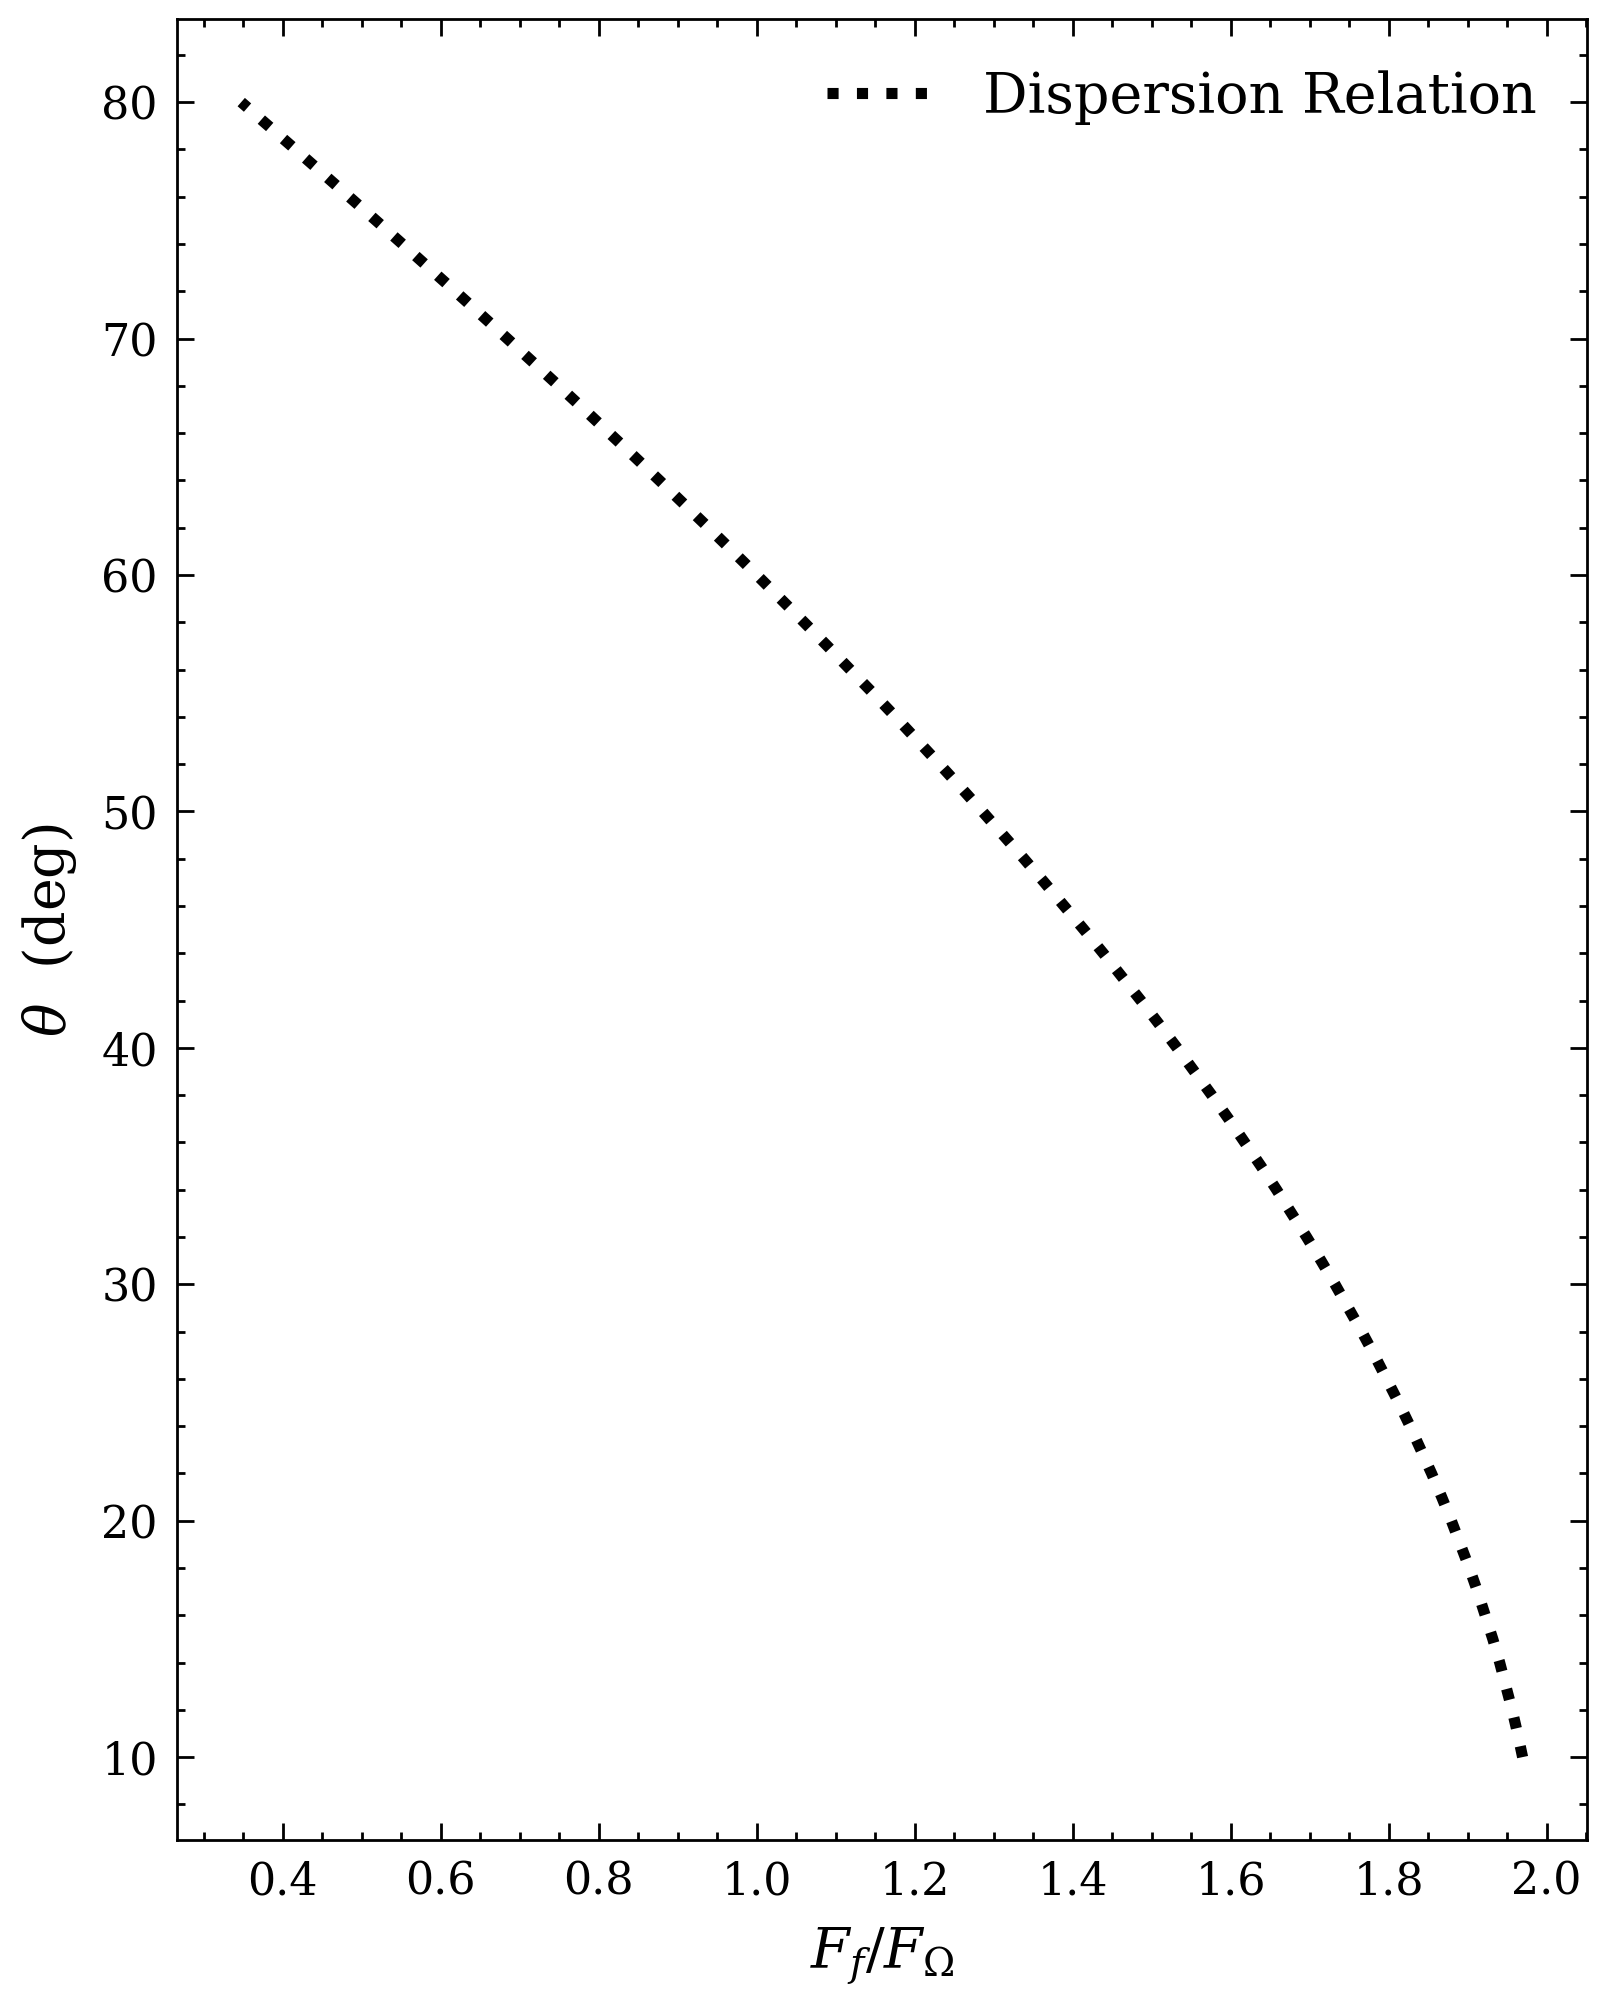

In [3]:
h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
Vels = ['U200']
Len = ['L100']
RPMs = ['RPM0', 'RPM3' ,'RPM6', 'RPM9', 'RPM12']

vels = h5file['Wide'][Vels[0]][Len[0]][RPMs[0]]
u = vels[:,:,:,0]
v = vels[:,:,:,1]

u = np.mean(u, axis=0)
v = np.mean(v, axis=0)

fps = np.array([60], dtype=int)
PRPM = np.array([2, 4, 8, 16, 32], dtype=int)
vel0 = 0.01162 * PRPM / 2
q0 = 0.000000329 * PRPM / 2

rpm = np.array([0, 1, 2, 3, 6, 9, 12])
RealRpm = np.array([0, 1, 2, 3, 6, 9, 12]) # 29.88,

nRot = rpm.shape[0]
nInj = PRPM.shape[0]

d = 0.006

ReArr       = np.zeros((nRot, nInj))
RoArr       = np.zeros((nRot, nInj))
EkArr       = np.zeros((nRot, nInj))

# mask = h5file['MISC']['Mask']
# ExX = mask.shape[1]
# ExY = mask.shape[0]
# proportion = ExY / ExX

f1, ax1s = plt.subplots(nrows=1, ncols=1, figsize = (4, 5))

r, z = oj.NDUnitsForPlotsWide(u.shape[0], u.shape[1])
X, Y = np.meshgrid(r, z)

Angles = np.linspace(10, 80, dtype='int')
# Angles= np.array([20, 30, 40, 50, 60, 70, 80])
# left = 31
# right = 53
left  = 71
right = 73
left  = 59###############Temp line
right = 60###############Temp line

left  = int(u.shape[1]/2)###############Temp line
right = int(u.shape[1]-(u.shape[1]/2))###############Temp line


runRot = 6
runInj = 1

## Import flow field 
# data = h5file['Narrow'][Vels[0]][Len[0]]['RPM{0}'.format(rpm[runRot])]
# data = h5file['RPM{0}'.format(rpm[runRot])]['INJ{0}'.format(PRPM[runInj])]
data = h5file['Wide'][Vels[0]][Len[0]]['RPM12']

uTemp = data[:, :, : ,0] #* mask #/ vel0[runInj]
vTemp = data[:, :, : ,1] #* mask #/ vel0[runInj]
h5file.close()

uTemp = np.rot90(u)###############Temp line
vTemp = v###############Temp line

vmean = np.mean(vTemp, axis=0)
vmean = np.mean(uTemp, axis=0) ###############Temp line
angMean = np.zeros(Angles.shape[0])
oj.tic()
for i in range(Angles.shape[0]):
    oj.progressBar(i, Angles.shape[0])
    ang = Angles[i]
    print(ang)

    if ang == 60:
        angMean[i] = 0 
    else:
        IWsF = oj.IWFilter(uTemp, ang, fps=60, rpm = 12)#, phase = 1)
        # IWsF = oj.IWFilter(uTemp, ang, fps=fps[runInj], rpm = RealRpm[runRot])###############Temp line
        # print(IWsF.shape)

        _,_,_,_,_,_,angDL = oj.TwoPtCorrIWs(IWsF[:, 2:, :left])
        _,_,_,_,_,_,angDR = oj.TwoPtCorrIWs(IWsF[:, 2:, right:])
        angD = (angDL+angDR)/2
        angMean[i] = angD
angMean = oj.InterpZeros(angMean)

oj.toc()

FByOmega = 2 * np.cos(np.deg2rad(Angles)) 

ax1s.plot(FByOmega, Angles, linestyle="dotted", color = 'black', label = 'Dispersion Relation')
ax1s.plot(FByOmega, angMean, color='blue', linestyle="none", marker=".", markersize=5, alpha=0.75)#, label = 'Ek - {}'.format(np.round(sb.Ek(RealRpm[runRot]), 4)))
ax1s.legend()

plt.setp(ax1s, xlabel=r'$F_{f} / F_{\Omega}$')
plt.setp(ax1s, ylabel=r"$\theta$  (deg)")

# f1.savefig('/Users/sambooth/Desktop/Thesis Bits/Ch7/VLS_2PtSingle.png', bbox_inches='tight')

plt.show()